<a href="https://colab.research.google.com/github/Rukaya-lab/Engineering-ML-Features-for-MOF-CO2-Adsorption/blob/main/ZI_model_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

In [ ]:
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
!pip uninstall -y Cython scipy pyparsing scikit_learn imbalanced-learn mlxtend yellowbrick

In [ ]:
!pip install Cython==0.29.36 scipy==1.9 pyparsing==2.4

In [ ]:
# 3. install older scikit-learn disregarding its dependencies
!pip install scikit-learn==0.24.2 --no-build-isolation

In [ ]:
!pip install --upgrade PyDrive2

In [ ]:
# 4. finally install auto-sklearn
!pip install auto-sklearn

# 5. then, try loading the package repeatedly until trash in its dependencies are clean
import autosklearn

In [ ]:
import autosklearn.regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from xgboost import XGBRegressor
import pickle
import joblib
import os

#import plotly.io as pio
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
oxy_data = pd.read_csv("/content/crafted_oxy_features.csv")
oxy_data.head()

,FrameworkName,0.001bar_mol_kg,0.1bar_mol_kg,0.5bar_mol_kg,10bar_mol_kg,LCD,PLD,Access_SA_m2/g,Density,AV_cm3_g,...,Value_792,Value_793,Value_794,Value_795,Value_796,Value_797,Value_798,Value_799,Value_800,Value_801
0,MUVHER,0.051678,2.484930,4.850875,7.381888,5.24679,3.73170,1841.510,0.97664,0.075038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,LACJAC,0.039919,1.350102,1.892201,2.696235,4.56325,3.36486,619.328,1.59158,0.022236,...,0.145395,0.035184,0.039586,0.032379,0.022074,0.019280,0.033410,0.056097,0.080166,0.089778
2,ZNGLUD,0.115857,2.458963,3.347351,4.426935,3.19455,2.66271,0.000,1.65404,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,AMUCOB,0.005819,0.359966,0.688829,1.120526,4.03894,3.31743,217.564,1.59335,0.004983,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,MIL-88C-open,0.002726,0.258265,1.282425,20.345104,13.75037,10.89185,4181.320,0.50854,0.973376,...,0.604458,0.313116,0.142669,0.047826,0.121876,0.201848,0.221202,0.244819,0.241008,0.233171


In [ ]:
co2_data = pd.read_csv("/content/crafted_co2_features.csv")
co2_data.head()

,FrameworkName,0.001bar_mol_kg,0.1bar_mol_kg,0.5bar_mol_kg,10bar_mol_kg,LCD,PLD,Access_SA_m2/g,Density,AV_cm3_g,...,Value_96,Value_97,Value_98,Value_99,Value_100,Value_101,Value_102,Value_103,Value_104,Value_105
0,MUVHER,0.051678,2.484930,4.850875,7.381888,5.24679,3.73170,1841.510,0.97664,0.075038,...,1.354581,0.544345,0.255109,0.180581,0.297404,0.886362,0.863493,0.612897,0.586592,0.586390
1,LACJAC,0.039919,1.350102,1.892201,2.696235,4.56325,3.36486,619.328,1.59158,0.022236,...,0.467836,0.233402,0.120943,0.082777,0.067073,0.068984,0.116780,0.189196,0.201302,0.195512
2,ZNGLUD,0.115857,2.458963,3.347351,4.426935,3.19455,2.66271,0.000,1.65404,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,AMUCOB,0.005819,0.359966,0.688829,1.120526,4.03894,3.31743,217.564,1.59335,0.004983,...,0.293981,0.064107,0.019796,0.031426,0.043740,0.039448,0.049880,0.028289,0.020651,0.104077
4,MIL-88C-open,0.002726,0.258265,1.282425,20.345104,13.75037,10.89185,4181.320,0.50854,0.973376,...,0.948326,0.726510,0.647695,0.662752,0.708436,0.689223,0.685165,0.666393,0.723089,0.720924


In [ ]:
def data_targets(data, target):
  df = data.iloc[:, target]
  df_t = np.array(df)
  return df_t

def target_names(data, target):
   names = data.columns[target]
   return 'Prediction:', names

Geometric Features

In [ ]:
def g_data_features(data):
  df = data.iloc[:, 5:10]
  df_n = np.array(df)
  return df_n

Geometric Features +  Histogram features

In [ ]:
def h_data_features(data):
  df = data.iloc[:, 5:115]
  df_n = np.array(df)
  return df_n

#for co2 total
def co2_hist_features(data):
  df = data.iloc[:, 5:19]
  df_n = np.array(df)
  return df_n

Geometric features + Histogram + Rdf

In [ ]:
def all_features(data):
  df = data.iloc[:, 5:]
  df_n = np.array(df)
  return df_n

Geometric features  + Rdf

In [ ]:
def rdf_oxy_features(data):
    # Selecting columns from 5 to 10 and from 115 onwards
    df1 = data.iloc[:, 5:10]  # geometric
    df2 = data.iloc[:, 115:]  # rdfs
    df = pd.concat([df1, df2], axis=1)
    df_n = np.array(df)
    return df_n

def co2_rdf_features(data):
    # Selecting columns from 5 to 10 and from 19 onwards
    df1 = data.iloc[:, 5:10]  # geometric
    df2 = data.iloc[:, 19:]   # rdf
    df = pd.concat([df1, df2], axis=1)
    df_n = np.array(df)
    return df_n

In [ ]:
for i in range(1,5):
  print(target_names(oxy_data, i))

('Prediction:', '0.001bar_mol_kg')
('Prediction:', '0.1bar_mol_kg')
('Prediction:', '0.5bar_mol_kg')
('Prediction:', '10bar_mol_kg')


# xgb Regressor

In [ ]:
#Train function
# Train function with cross-validation and grid search

# Define paths in Google Drive
model_save_path = '/content/drive/MyDrive/UoM Dissertation/result/models'
prediction_save_path = '/content/drive/MyDrive/UoM Dissertation/result/predictions'

def train(model, data, target, features_fxn, save_prefix, cv=3, param_grid=None):
    data = data.fillna(0)
    target_name = target_names(data, target)
    features = features_fxn(data)
    targets = data_targets(data, target)

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(features, targets, train_size=0.78, random_state=42)

    # If no param_grid is provided, use a default one
    if param_grid is None:
        param_grid = {
            'n_estimators': [500, 1000, 2000],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7]
        }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=-1)

    # Fit the model using grid search and cross-validation on the training set
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Cross-validation scores on the training set
    scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='r2')
    mean_cv_score = scores.mean()

    # Fit the best model on the entire training set
    best_model.fit(X_train, y_train)

    # Prediction on the test set
    y_pred = best_model.predict(X_test)

    r_score = r2_score(y_test, y_pred)

    # Print results
    print(target_name)
    print('R_squared on test set: ', r_score)
    print(f'Cross-validated R_squared (mean of {cv} folds): ', mean_cv_score)

    # Save the best model
    model_filename = os.path.join(model_save_path, f'{save_prefix}_{target_name[1].split("_")[0]}_xgb_model.joblib')
    joblib.dump(best_model, model_filename)

    # Save the predictions
    predictions_filename = os.path.join(prediction_save_path, f'{save_prefix}_{target_name[1].split("_")[0]}_xgb_predictions.txt')
    np.savetxt(predictions_filename, y_pred, fmt='%f')

    # Plot predictions vs actual results
    plt.scatter(y_test, y_pred)
    plt.title(f'Prediction vs GCMC result at {target_name[1].split("_")[0]}')
    plt.xlabel('GCMC CO2 uptake [mol/kg]', fontsize=10, fontweight='bold')
    plt.ylabel('ML Predicted CO2 uptake [mol/kg]', fontsize=10, fontweight='bold')

    # Calculate min and max values for the axis limits
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    # Plot your data
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')  # Black diagonal line

    # Set limits to ensure the same scale and include all points
    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    #plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--')  # Black diagonal line
    plt.text(0.05, 0.95, f'R²: {r_score:.3f}', ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, fontweight='bold')
    plt.show()


## Geometric Features

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  -0.7445850008061667
Cross-validated R_squared (mean of 3 folds):  0.21242666225879414


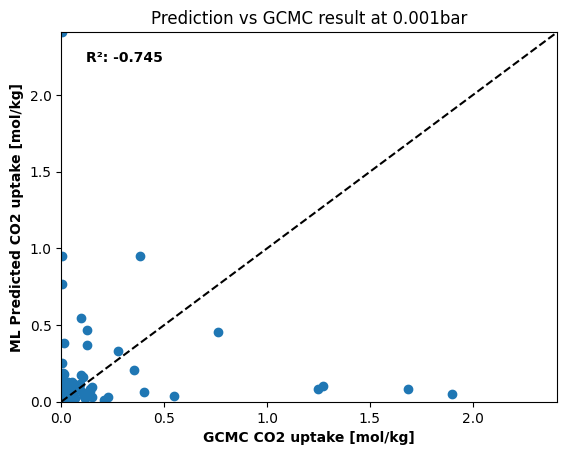

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.2209072006946805
Cross-validated R_squared (mean of 3 folds):  0.35341343927840146


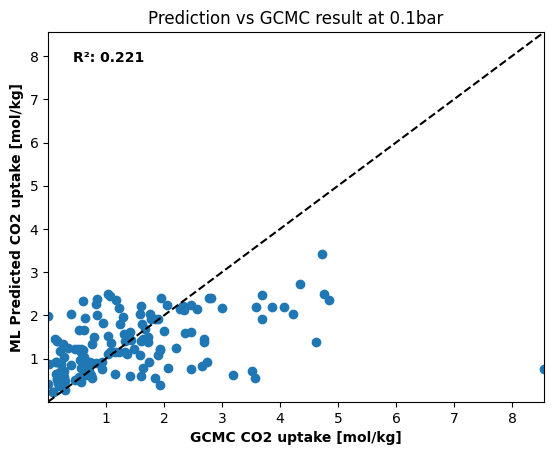

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.40679629128266426
Cross-validated R_squared (mean of 3 folds):  0.45515009165655035


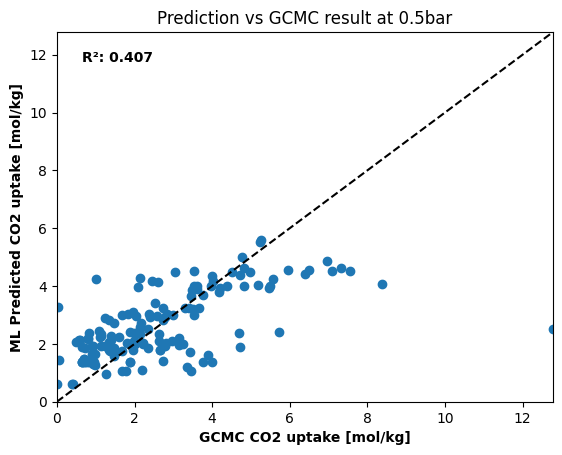

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9168922662256935
Cross-validated R_squared (mean of 3 folds):  0.9215432193196147


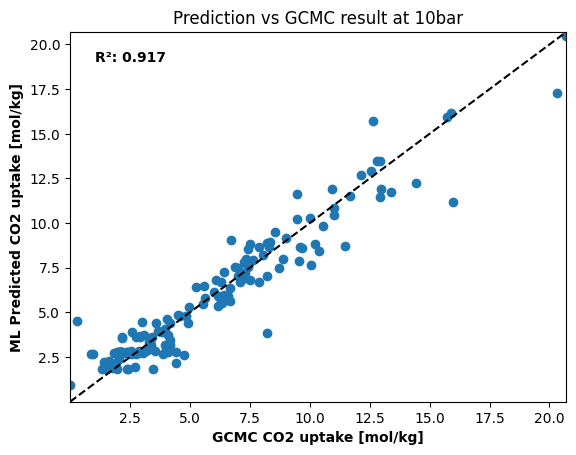

In [ ]:
model = XGBRegressor(random_state=42)
for i in range(1,5):
  train(model, oxy_data, i, g_data_features, save_prefix= 'geometric')

## Geometric Features  + Histogram features

### OXYGEN PROBE

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.4827210342327558
Cross-validated R_squared (mean of 3 folds):  0.34951414097791506


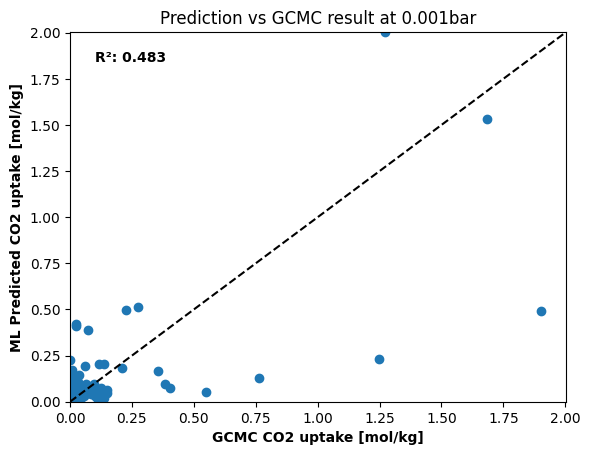

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.49626018218189394
Cross-validated R_squared (mean of 3 folds):  0.5315870530363593


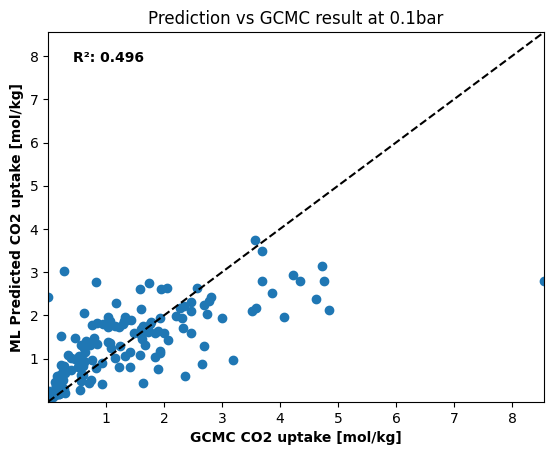

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.6088855455336324
Cross-validated R_squared (mean of 3 folds):  0.5749285305587274


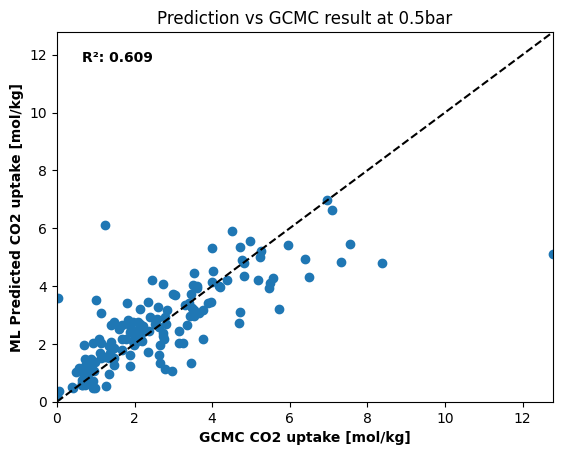

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9219592490772939
Cross-validated R_squared (mean of 3 folds):  0.9281863151651208


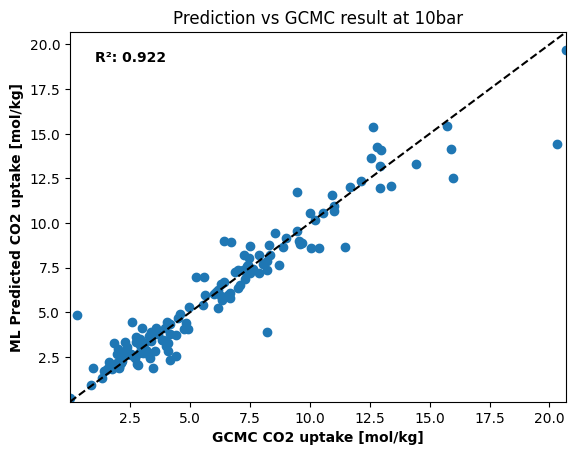

In [ ]:
#model = XGBRegressor(n_estimators=2000, learning_rate=0.05, random_state=42)
for i in range(1,5):
  train(model, oxy_data, i, h_data_features, save_prefix= 'geo + hist (oxy)')

## CO2 **probe**

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  -0.13345029447257395
Cross-validated R_squared (mean of 3 folds):  0.48829703118775175


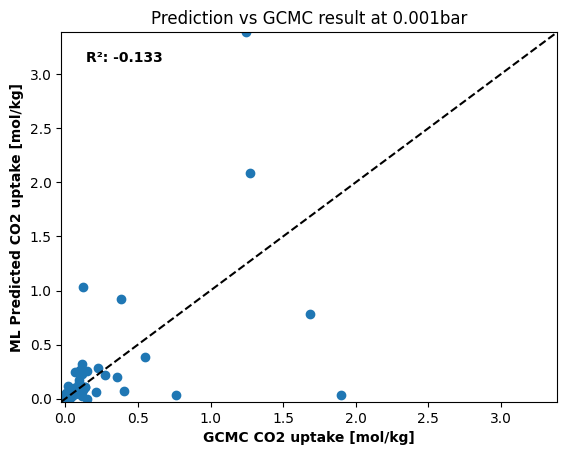

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.676225992771571
Cross-validated R_squared (mean of 3 folds):  0.7638995548161117


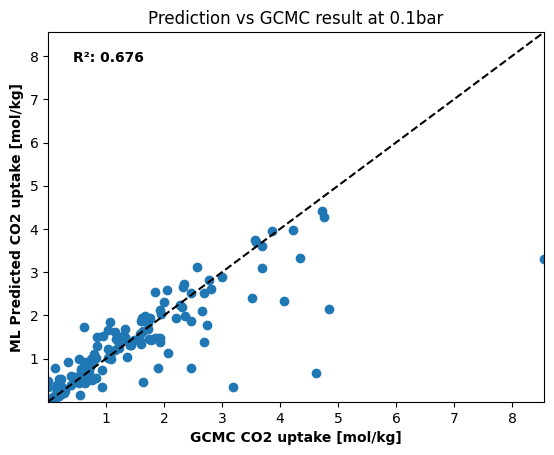

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.7998084102727
Cross-validated R_squared (mean of 3 folds):  0.7754561537208268


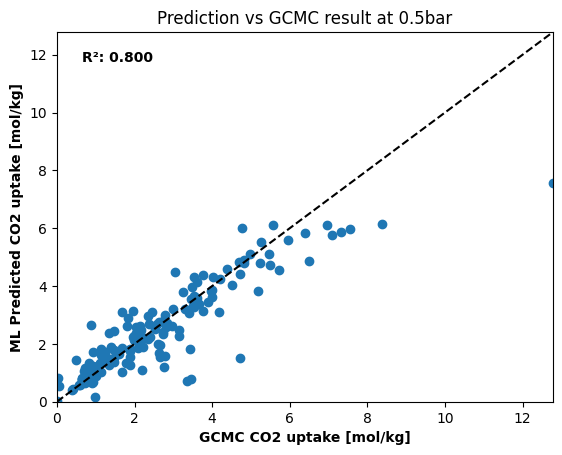

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9343978375072384
Cross-validated R_squared (mean of 3 folds):  0.9397659523928271


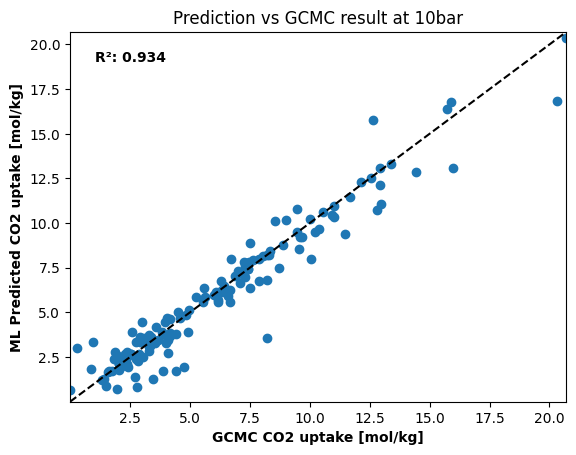

In [ ]:

for i in range(1,5):
  train(model, co2_data, i, co2_hist_features, save_prefix= 'geo + hist (co2)')

## Geometric features+ Rdf

### oxygen probe

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  -0.25260348673710276
Cross-validated R_squared (mean of 3 folds):  0.18396240403508388


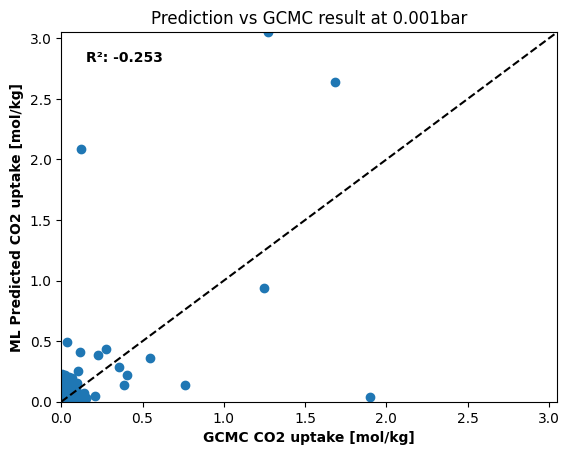

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.523750707254089
Cross-validated R_squared (mean of 3 folds):  0.6446388374645952


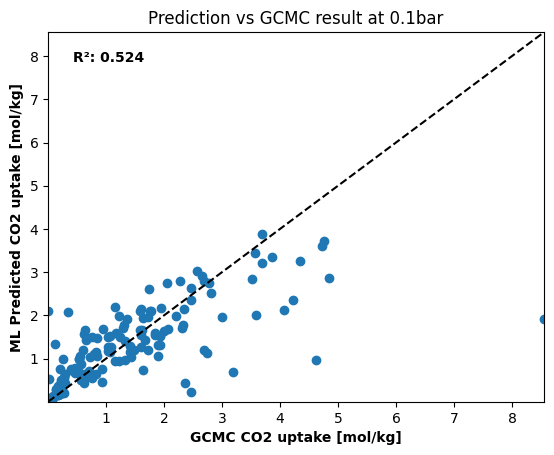

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.6941674278707408
Cross-validated R_squared (mean of 3 folds):  0.6522171595158147


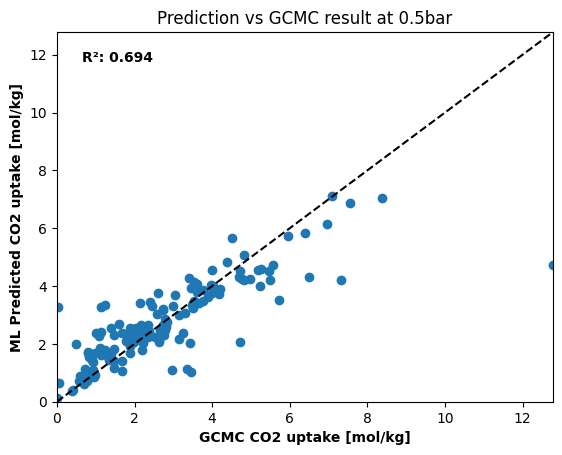

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.920421765963169
Cross-validated R_squared (mean of 3 folds):  0.9436273480215002


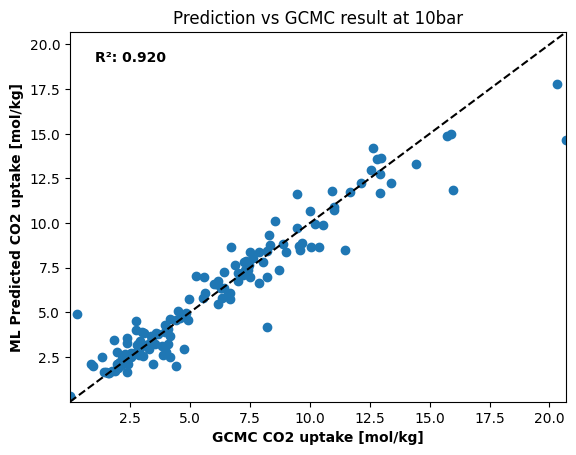

In [ ]:
model = XGBRegressor(random_state=42)
for i in range(1,5):
  train(model, oxy_data, i, rdf_oxy_features, save_prefix= 'geo + rdf (oxy)')

### CO2 probe

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.431175868616528
Cross-validated R_squared (mean of 3 folds):  0.34645339885559406


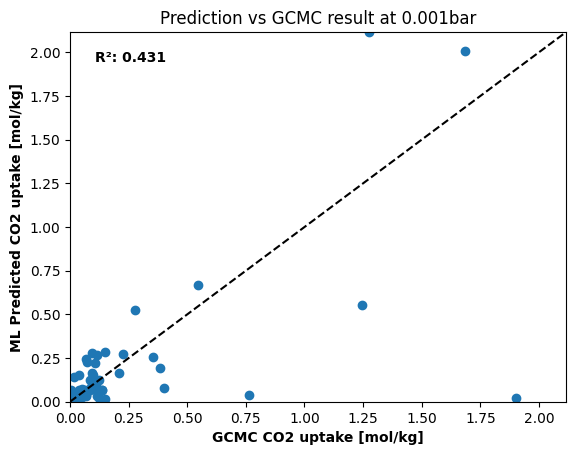

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.7389581392682244
Cross-validated R_squared (mean of 3 folds):  0.8034007417525428


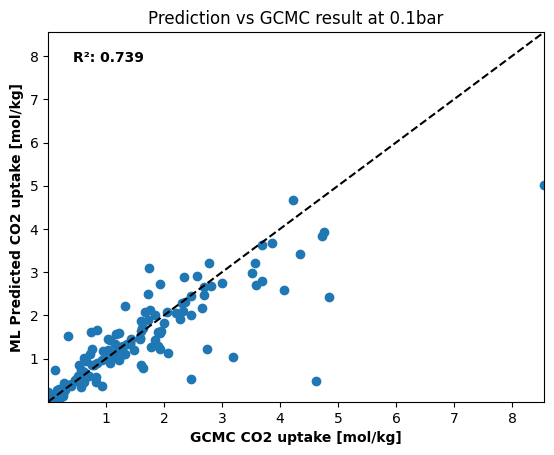

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.8099589461405862
Cross-validated R_squared (mean of 3 folds):  0.830389899825214


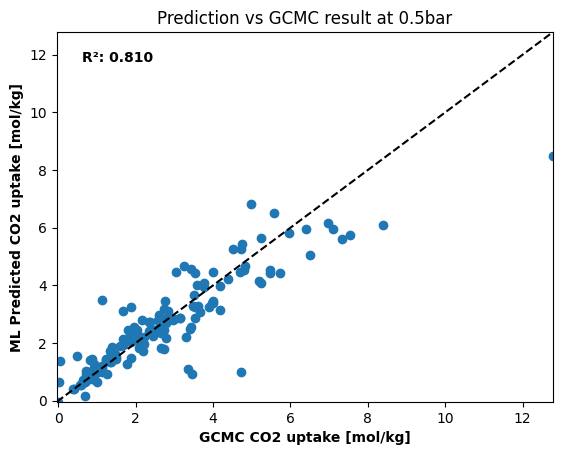

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9224646827128382
Cross-validated R_squared (mean of 3 folds):  0.9513461358820084


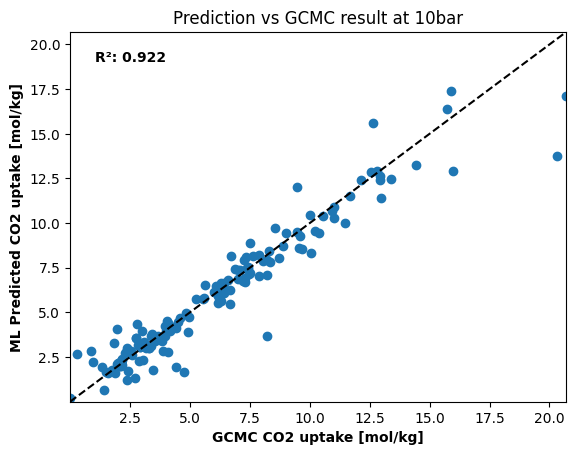

In [ ]:
model = XGBRegressor(random_state=42)
for i in range(1,5):
  train(model, co2_data, i, co2_rdf_features, save_prefix= 'geo + rdf (co2)')

## Geometric features + Hist + Rdf

### oxygen probe

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  -0.6553790571297884
Cross-validated R_squared (mean of 3 folds):  0.16678642880881936


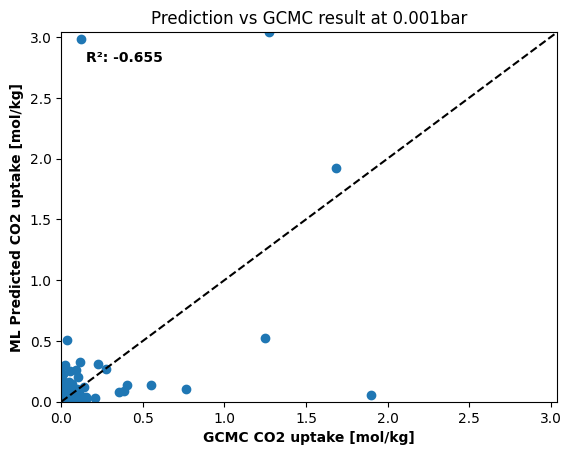

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.5357012567926897
Cross-validated R_squared (mean of 3 folds):  0.6484062881166248


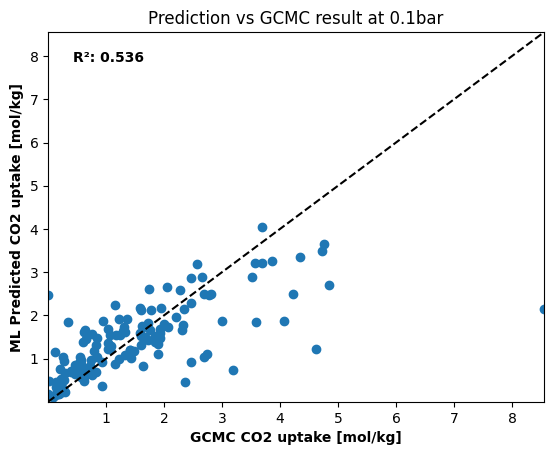

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.6973730816249217
Cross-validated R_squared (mean of 3 folds):  0.6611890013800732


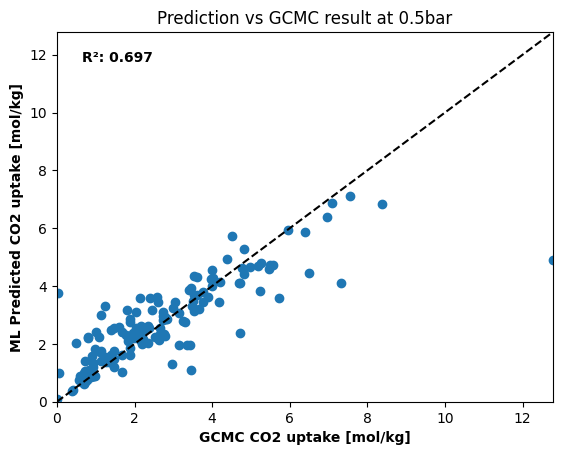

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.915293181652541
Cross-validated R_squared (mean of 3 folds):  0.9425103029397399


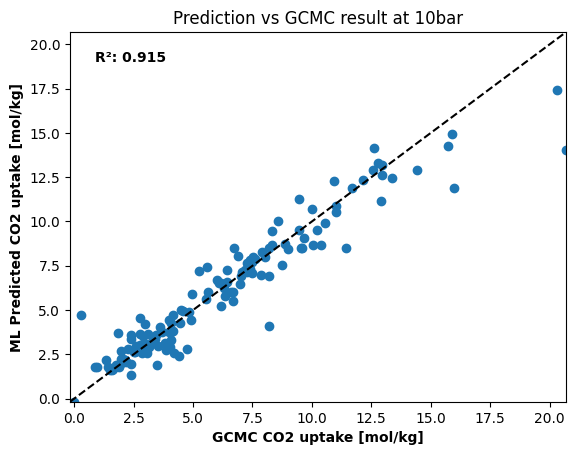

In [ ]:
model = XGBRegressor( random_state=42)
for i in range(1,5):
  train(model, oxy_data, i, all_features, save_prefix= 'all (oxy)')

### CO2 Probe

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  -0.2940563679368149
Cross-validated R_squared (mean of 3 folds):  0.5391678455354334


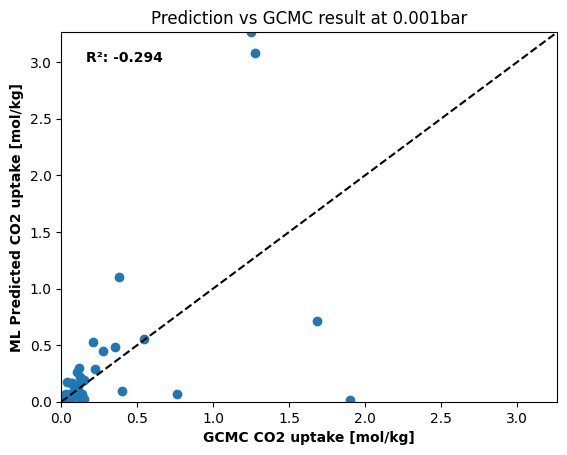

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.7318850989510948
Cross-validated R_squared (mean of 3 folds):  0.798365626484235


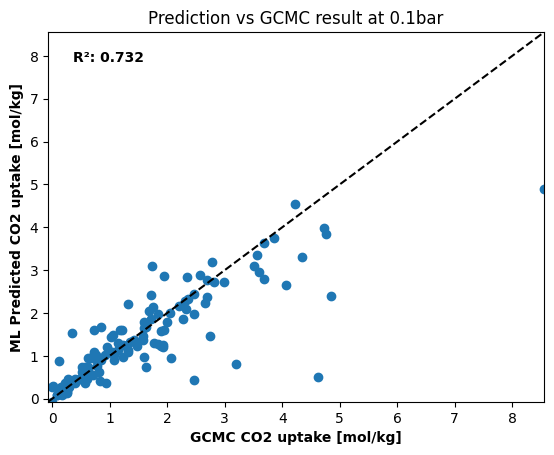

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.8137944358478113
Cross-validated R_squared (mean of 3 folds):  0.8269915398514631


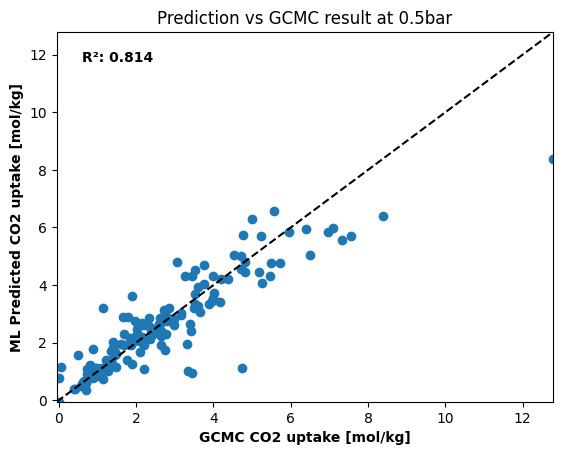

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.915640249793798
Cross-validated R_squared (mean of 3 folds):  0.9499759564253877


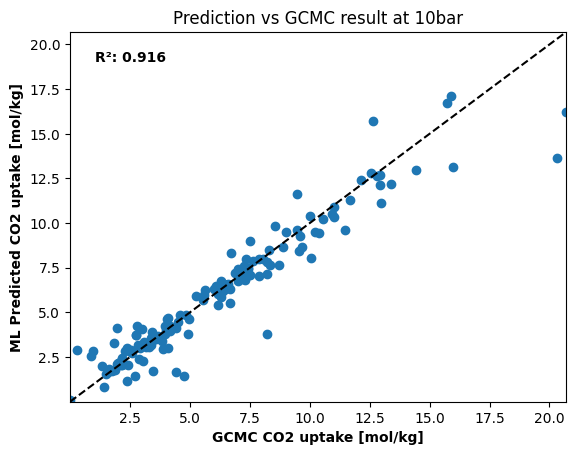

In [ ]:
#model = XGBRegressor(n_estimators=2000, learning_rate=0.05, random_state=42)
for i in range(1,5):
  train(model, co2_data, i, all_features, save_prefix= 'all (co2)')

# AUTO-ML

In [ ]:

# Define paths in Google Drive
model_save_path = '/content/drive/MyDrive/UoM Dissertation/result/models'
prediction_save_path = '/content/drive/MyDrive/UoM Dissertation/result/predictions'


# Train function with auto-sklearn
def train_autoML(data, target, features_fxn, save_prefix, time_left_for_this_task=3600, per_run_time_limit=300):
    data = data.fillna(0)
    target_name = target_names(data, target)
    features = features_fxn(data)
    targets = data_targets(data, target)

    # Split data for initial training and testing
    X_train, X_test, y_train, y_test = train_test_split(features, targets, train_size=0.78, random_state=42)

    # Initialize auto-sklearn regressor
    automl = autosklearn.regression.AutoSklearnRegressor(
        time_left_for_this_task=time_left_for_this_task,
        per_run_time_limit=per_run_time_limit,
        metric=autosklearn.metrics.r2,
        n_jobs=6,
        ensemble_kwargs={'ensemble_size': 4}
    )

    # Fit the model using auto-sklearn
    automl.fit(X_train, y_train)

    # Get the best model
    y_pred = automl.predict(X_test)

    r_score = r2_score(y_test, y_pred)

    # Print results
    print(target_name)
    print('R_squared on test set: ', r_score)
    print(automl.leaderboard())

    # Save the model with joblib
    model_filename = os.path.join(model_save_path, f'{save_prefix}_{target_name[1].split("_")[0]}_auto_model.joblib')
    joblib.dump(automl, model_filename)

    # Save the predictions
    predictions_filename = os.path.join(prediction_save_path, f'{save_prefix}_{target_name[1].split("_")[0]}_auto_predictions.txt')
    np.savetxt(predictions_filename, y_pred, fmt='%f')

    # Plot predictions vs actual results with consistent axis scales
    plt.scatter(y_test, y_pred)
    plt.title(f'Prediction vs GCMC result at {target_name[1].split("_")[0]} pressure')
    plt.xlabel('Actual CO2 uptake / (mol/kg)', fontsize=10, fontweight='bold')
    plt.ylabel('ML Predicted CO2 uptake /(mol/kg)', fontsize=10, fontweight='bold')
    # Calculate min and max values for the axis limits
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    # Plot your data
    plt.plot([min_val + 0.5 , max_val - 0.5], [min_val+0.5, max_val-0.5], 'k--')  # Black diagonal line

    # Set limits to ensure the same scale and include all points
    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    #plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--')  # Black diagonal line
    plt.text(0.05, 0.95, f'R²: {r_score:.3f}', ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, fontweight='bold')
    plt.show()


## Geometric Features

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.03420271956227228
          rank  ensemble_weight           type      cost  duration
model_id                                                          
384          1             0.75    extra_trees  0.950717  2.570261
319          2             0.25  random_forest  1.000553  4.305158


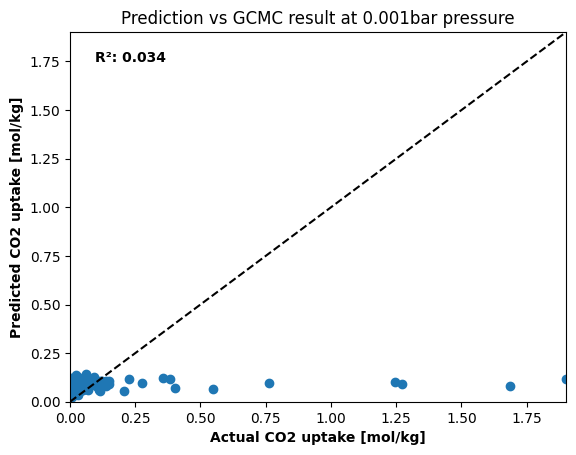

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.2259055615401
          rank  ensemble_weight           type      cost   duration
model_id                                                           
102          1             0.50     libsvm_svr  0.459342   2.834236
50           2             0.25  decision_tree  0.480671   4.522613
108          3             0.25       adaboost  0.505271  11.775487


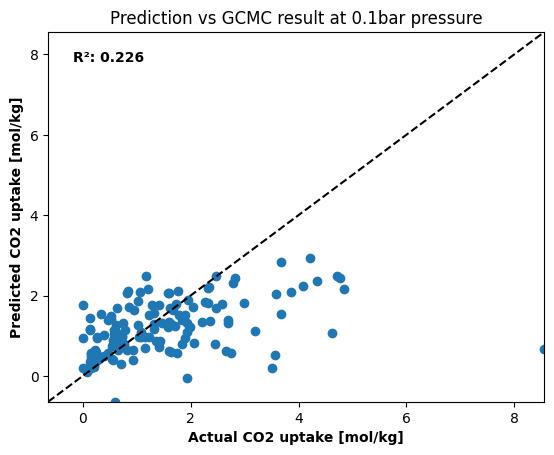

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.4407054241144256
          rank  ensemble_weight         type      cost   duration
model_id                                                         
279          1             0.25  extra_trees  0.422498  24.129032
232          2             0.25          sgd  0.462831   1.806401
99           3             0.25     adaboost  0.470359   2.959852
14           4             0.25   libsvm_svr  0.494525   4.499427


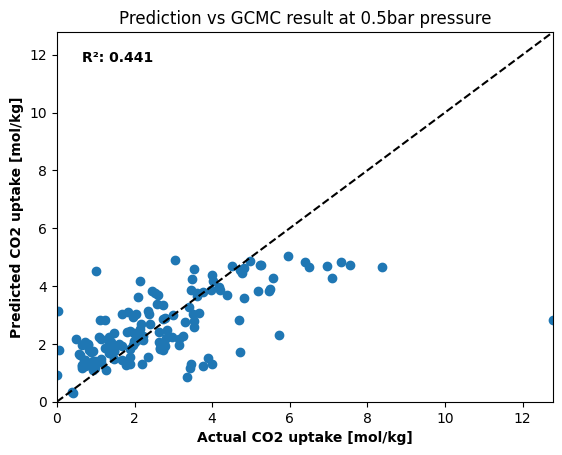

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.8883825755507557
          rank  ensemble_weight               type      cost  duration
model_id                                                              
81           1             0.50         libsvm_svr  0.059889  3.829580
70           2             0.25                sgd  0.068760  1.507493
433          3             0.25  gradient_boosting  0.073748  2.673495


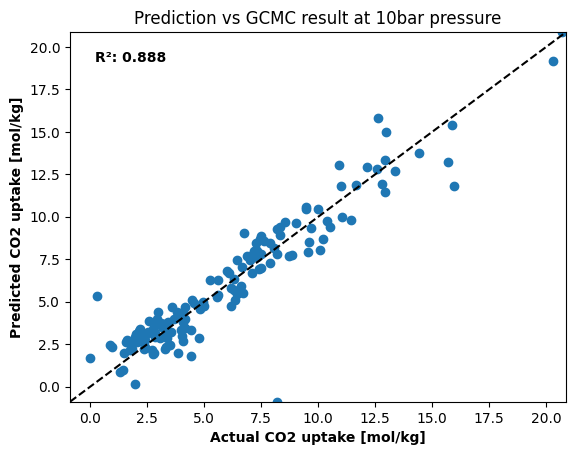

In [ ]:
for i in range(1,5):
  train_autoML(oxy_data, i, g_data_features, save_prefix= 'geometric')

## Geometric Features  + Histogram features

### OXYGEN PROBE

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.3905149174975171
          rank  ensemble_weight           type      cost   duration
model_id                                                           
149          1             0.50    extra_trees  0.806404  12.097672
21           2             0.25  liblinear_svr  0.958427  57.334389
239          3             0.25            mlp  0.997655   3.656558


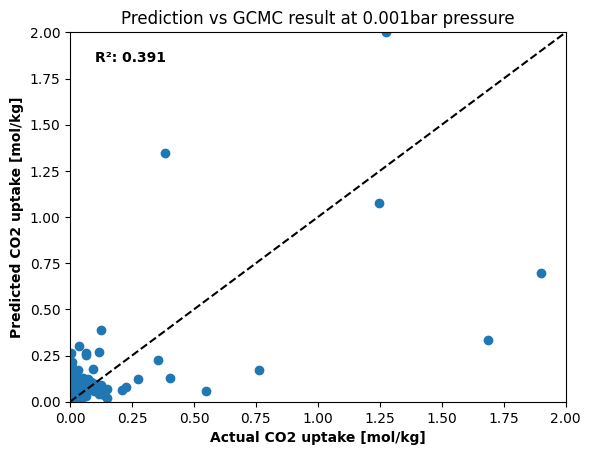

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.46117904641020335
          rank  ensemble_weight           type      cost   duration
model_id                                                           
18           1             0.25    extra_trees  0.361739  13.721520
204          2             0.25       adaboost  0.376160   2.894549
314          3             0.25  decision_tree  0.491402   1.287305
172          4             0.25            mlp  0.509898   6.602911


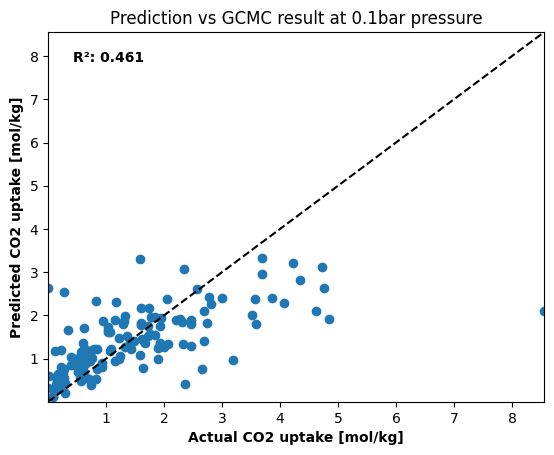

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.6573710917697367
          rank  ensemble_weight           type      cost   duration
model_id                                                           
18           1             0.25    extra_trees  0.299644  15.914189
222          2             0.25       adaboost  0.314499  13.708576
333          3             0.25  random_forest  0.361244  68.659029
19           4             0.25       adaboost  0.410285  32.821295


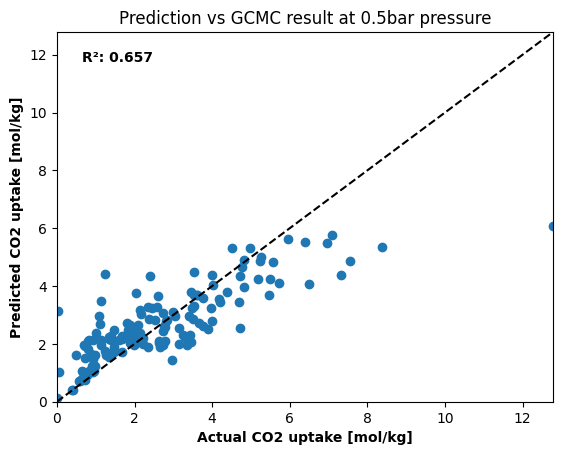

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9074040622134489
          rank  ensemble_weight         type      cost   duration
model_id                                                         
48           1             0.25     adaboost  0.051369  13.436667
274          2             0.25     adaboost  0.052181   4.891262
13           3             0.25  extra_trees  0.054192  57.240041
100          4             0.25     adaboost  0.063662  14.087801


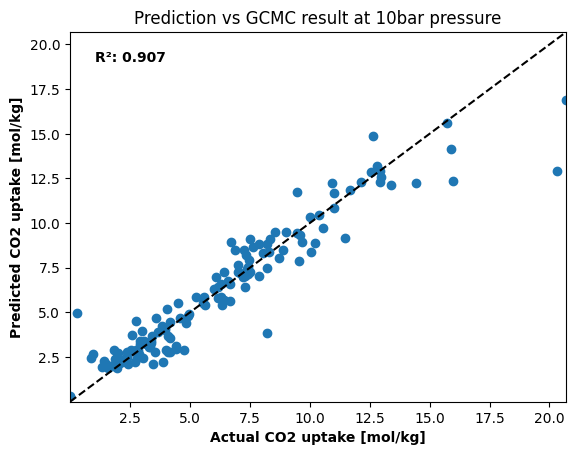

In [ ]:

for i in range(1,5):
  train_autoML(oxy_data, i, h_data_features, save_prefix= 'geo + hist (oxy)')

## CO2 **probe**

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.2019717662424455
          rank  ensemble_weight               type      cost   duration
model_id                                                               
16           1             0.50  gradient_boosting  0.313088  14.458178
3            2             0.25     ard_regression  0.364632   6.628503
411          3             0.25      decision_tree  0.458921   1.576294


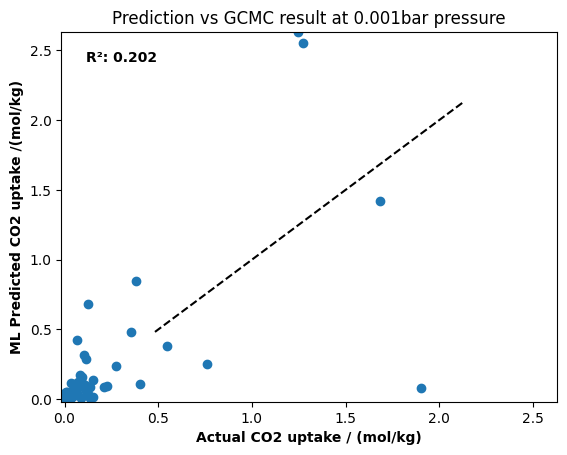

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.719166723252257
          rank  ensemble_weight               type      cost   duration
model_id                                                               
15           1             0.50   gaussian_process  0.142595  24.732582
14           2             0.25  gradient_boosting  0.165491  11.453340
3            3             0.25     ard_regression  0.188142   3.720323


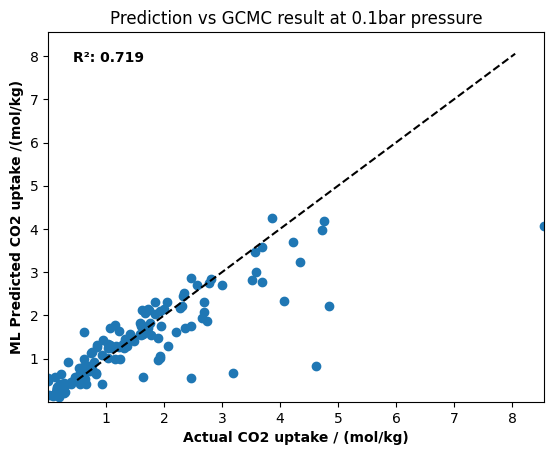

In [ ]:

for i in range(1,5):
  train_autoML( co2_data, i, co2_hist_features, save_prefix= 'geo + hist (co2)')

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.8306936531028772
          rank  ensemble_weight               type      cost   duration
model_id                                                               
15           1             0.25   gaussian_process  0.171681  27.014227
134          2             0.25  gradient_boosting  0.174208  48.064321
193          3             0.25  gradient_boosting  0.215075   5.089543
3            4             0.25     ard_regression  0.239489   5.556981


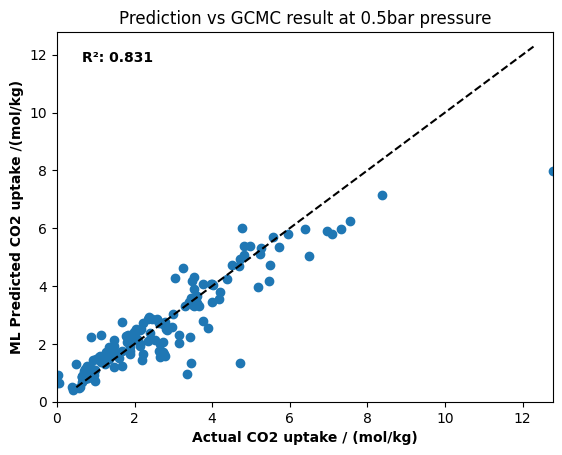

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9430362574438886
          rank  ensemble_weight               type      cost    duration
model_id                                                                
238          1             0.25           adaboost  0.040744   37.284992
14           2             0.25  gradient_boosting  0.046868   16.101268
21           3             0.25   gaussian_process  0.047941  214.139002
126          4             0.25         libsvm_svr  0.070081   42.089665


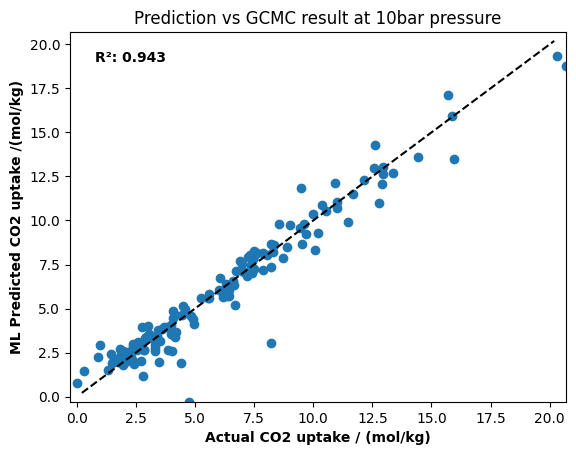

In [ ]:

for i in range(3,5):
  train_autoML( co2_data, i, co2_hist_features, save_prefix= 'geo + hist (co2)')

## Geometric features + Rdf

### Oxygen Probe

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.3781400048901544
          rank  ensemble_weight           type      cost   duration
model_id                                                           
155          1             0.50  random_forest  0.879678  59.675163
165          2             0.25       adaboost  0.923245   6.468912
178          3             0.25            sgd  0.927285  68.262248


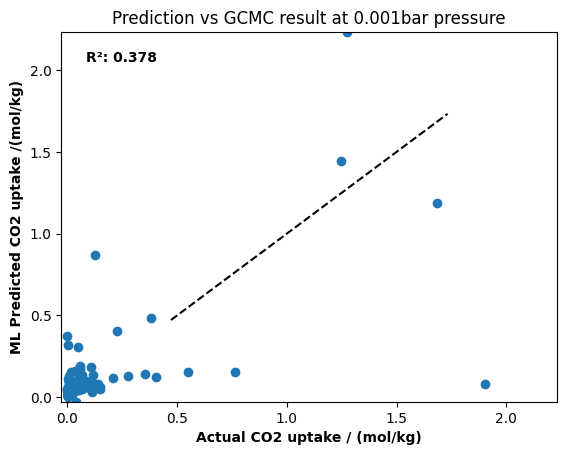

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.5555359328112162
          rank  ensemble_weight               type      cost    duration
model_id                                                                
192          1             0.25           adaboost  0.336126   55.177788
148          2             0.25  gradient_boosting  0.363380  147.830001
145          3             0.25                sgd  0.385613    2.761804
38           4             0.25                mlp  0.424840   26.190487


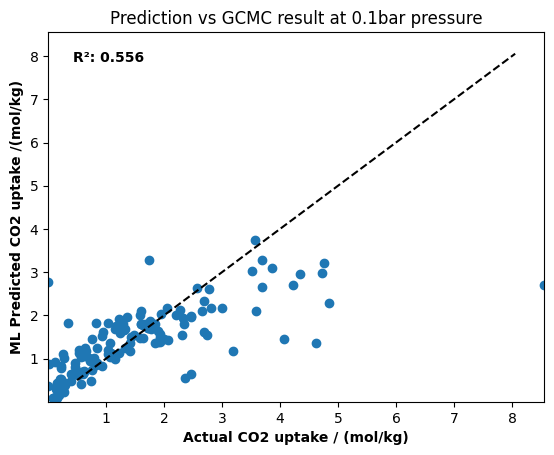

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.7068233999340915
          rank  ensemble_weight               type      cost    duration
model_id                                                                
2            1             0.25      random_forest  0.303545  126.301812
86           2             0.25  gradient_boosting  0.315237    8.288331
51           3             0.25      liblinear_svr  0.331042   15.275308
131          4             0.25     ard_regression  0.448223    8.886012


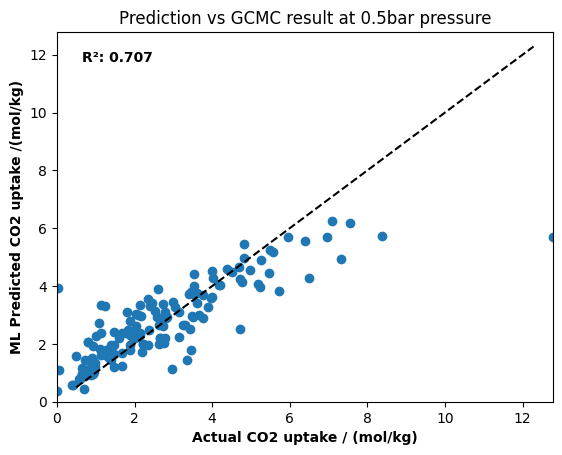

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9224069142393153
          rank  ensemble_weight            type      cost   duration
model_id                                                            
162          1             0.75        adaboost  0.044569  14.260041
213          2             0.25  ard_regression  0.078943   5.395305


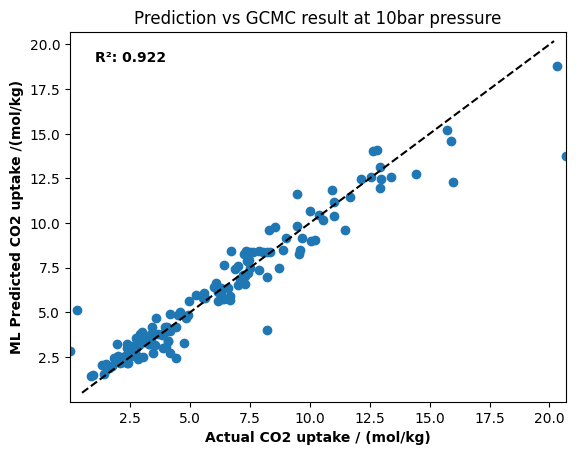

In [ ]:

for i in range(1,5):
  train_autoML(oxy_data, i, rdf_oxy_features, save_prefix= 'geo + rdf (oxy)')

### CO2 Probe

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.47507910552883215
          rank  ensemble_weight      type      cost   duration
model_id                                                      
270          1             0.25       sgd  0.221313   4.745312
153          2             0.25       mlp  0.259348   3.987113
121          3             0.25       mlp  0.447170  15.974829
182          4             0.25  adaboost  0.451658  27.391176


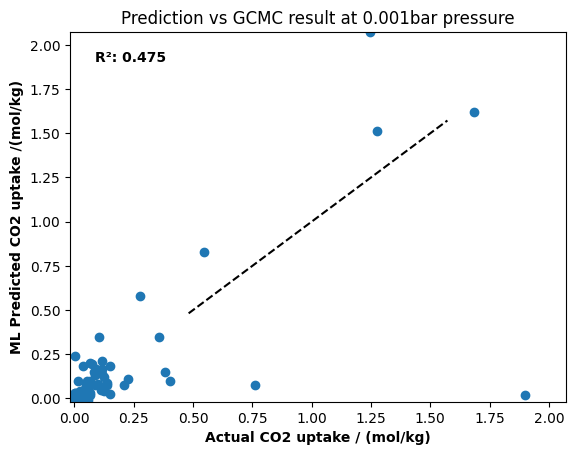

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.7313628337375242
          rank  ensemble_weight               type      cost    duration
model_id                                                                
114          1             0.25      liblinear_svr  0.114926    5.427906
6            2             0.25   gaussian_process  0.119214  227.070958
216          3             0.25  gradient_boosting  0.132079   11.992148
185          4             0.25           adaboost  0.179735    6.637846


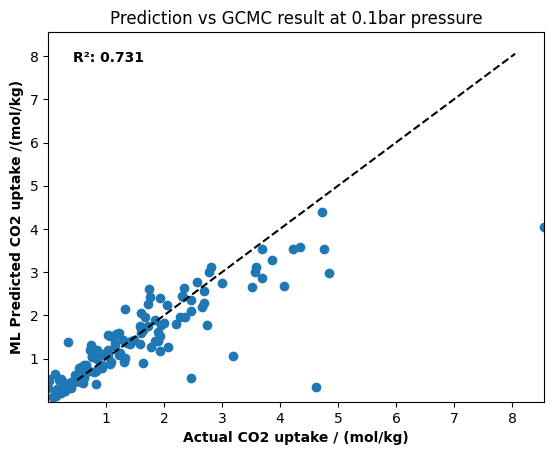

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.8207251759934466
          rank  ensemble_weight                 type      cost   duration
model_id                                                                 
59           1             0.25    gradient_boosting  0.122849  13.573058
190          2             0.25        liblinear_svr  0.147939   4.136469
231          3             0.25                  mlp  0.180421  22.323719
142          4             0.25  k_nearest_neighbors  0.201546   1.659520


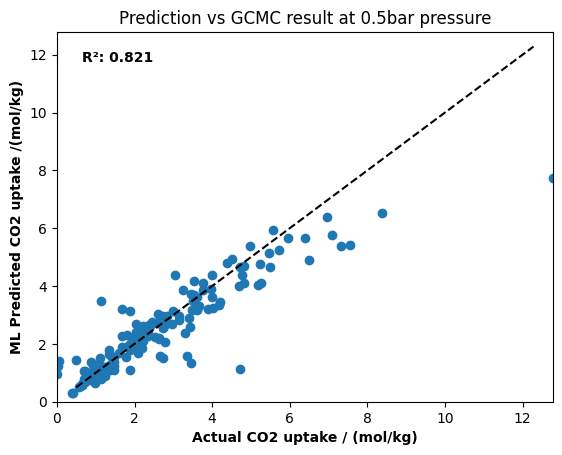

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9502978684317623
          rank  ensemble_weight              type      cost    duration
model_id                                                               
174          1             0.25          adaboost  0.036530   10.290921
7            2             0.25  gaussian_process  0.038413  117.773877
25           3             0.25        libsvm_svr  0.043479   15.966134
127          4             0.25     liblinear_svr  0.079476    3.116112


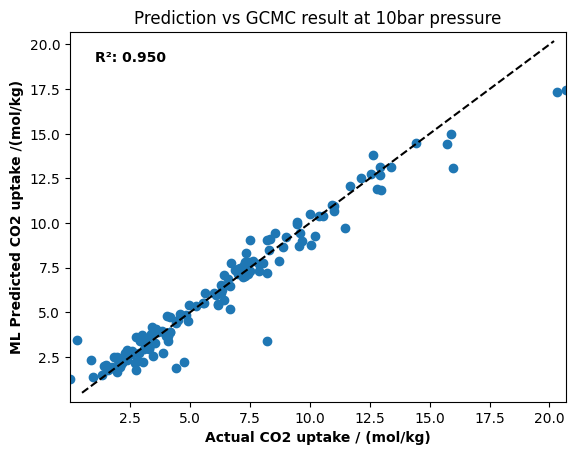

In [ ]:
for i in range(1,5):
  train_autoML( co2_data, i, co2_rdf_features, save_prefix= 'geo + rdf (co2)')

## Geometric features + Hist + Rdf

## Oxygen **probe**

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.2922832270787864
          rank  ensemble_weight        type      cost   duration
model_id                                                        
234          1             0.25    adaboost  0.886831  18.457093
40           2             0.25         sgd  0.918098   5.265608
99           3             0.25    adaboost  0.932288  14.243192
111          4             0.25  libsvm_svr  1.008485   4.612528


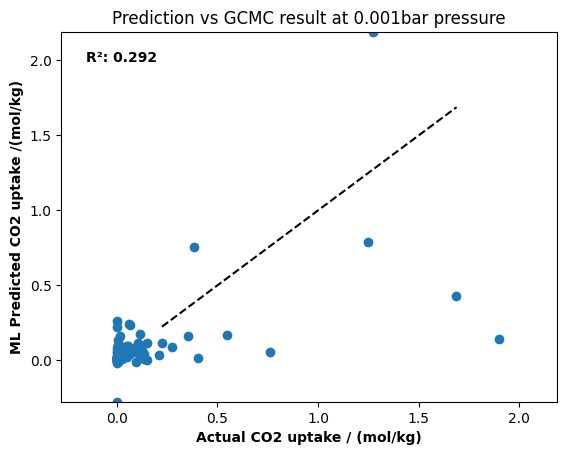

In [ ]:
for i in range(1,5):
  train_autoML( oxy_data, i, all_features, save_prefix= 'all (oxy)')

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.5473923557834235
          rank  ensemble_weight               type      cost   duration
model_id                                                               
39           1             0.25  gradient_boosting  0.320445  14.392023
134          2             0.25  gradient_boosting  0.359510  86.420696
243          3             0.25                sgd  0.405036   2.941627
257          4             0.25     ard_regression  0.408390  10.882849


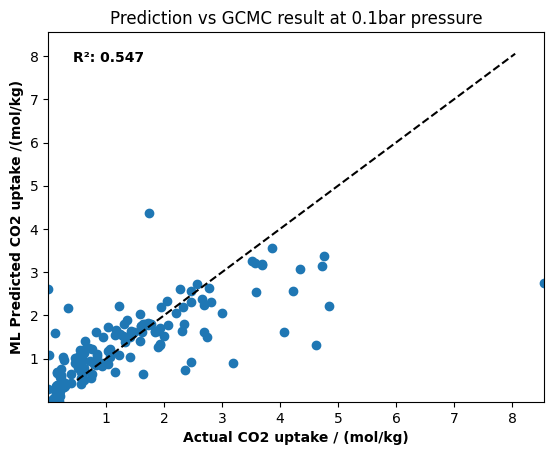

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.6718446902095256
          rank  ensemble_weight               type      cost    duration
model_id                                                                
2            1             0.25      random_forest  0.306128  137.576517
39           2             0.25        extra_trees  0.316577    8.671770
224          3             0.25  gradient_boosting  0.359552  143.876941
66           4             0.25     ard_regression  0.479726   14.861920


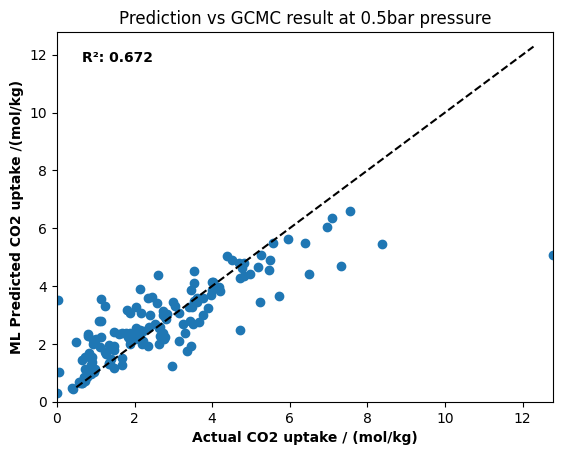

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.932826601446191
          rank  ensemble_weight               type      cost    duration
model_id                                                                
14           1             0.25        extra_trees  0.049677  275.130552
27           2             0.25        extra_trees  0.052776   17.935905
207          3             0.25  gradient_boosting  0.069518   17.969149
172          4             0.25                mlp  0.086473   13.053603


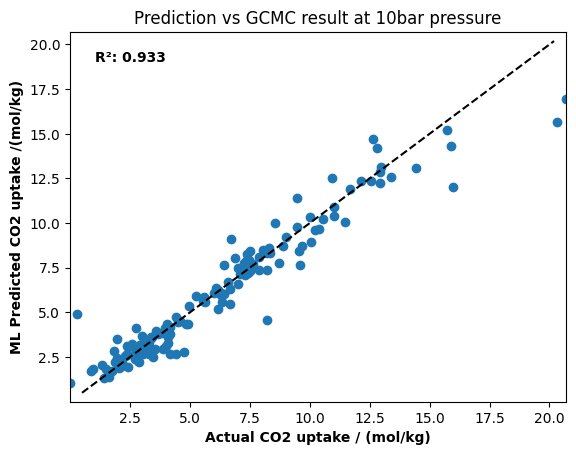

In [ ]:
for i in range(2,5):
  train_autoML( oxy_data, i, all_features, save_prefix= 'all (oxy)')

## CO2 **probe**

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.3022288383550994
          rank  ensemble_weight           type      cost  duration
model_id                                                          
263          1             0.25    extra_trees  0.344427  4.109340
138          2             0.25            sgd  0.412639  3.132827
42           3             0.25  liblinear_svr  0.421630  1.712719
76           4             0.25            mlp  0.567404  4.566245


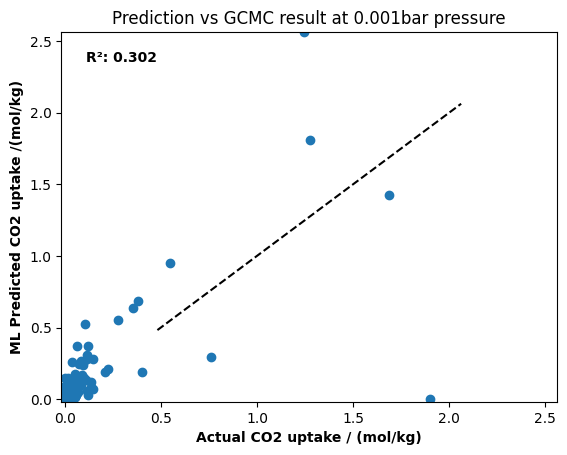

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.7682109234743508
          rank  ensemble_weight              type      cost   duration
model_id                                                              
22           1             0.25  gaussian_process  0.105842  93.177243
189          2             0.25               mlp  0.137504   5.730621
222          3             0.25  gaussian_process  0.151483  89.341182
83           4             0.25               mlp  0.183520   7.502179


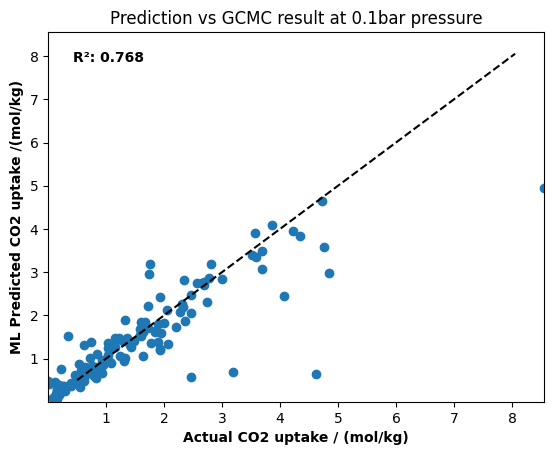

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.8403594582668404
          rank  ensemble_weight               type      cost   duration
model_id                                                               
260          1             0.25  gradient_boosting  0.140061   6.368643
109          2             0.25         libsvm_svr  0.155046   5.648995
162          3             0.25  gradient_boosting  0.197388  80.768010
25           4             0.25         libsvm_svr  0.212554  19.497796


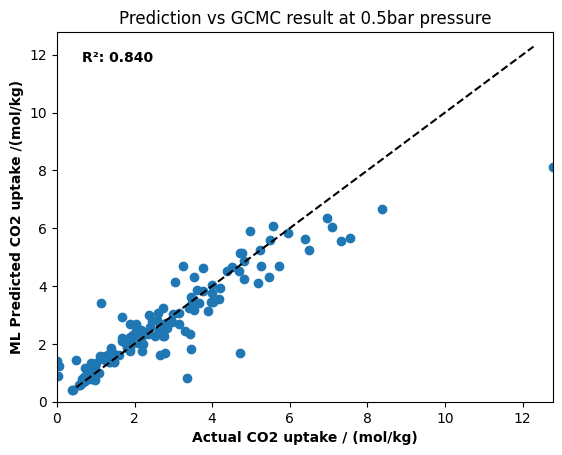

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.9489257457846849
          rank  ensemble_weight               type      cost   duration
model_id                                                               
64           1             0.25  gradient_boosting  0.033601  15.149362
4            2             0.25   gaussian_process  0.041766  72.331625
25           3             0.25         libsvm_svr  0.044030  15.621605
66           4             0.25      liblinear_svr  0.065763   1.986973


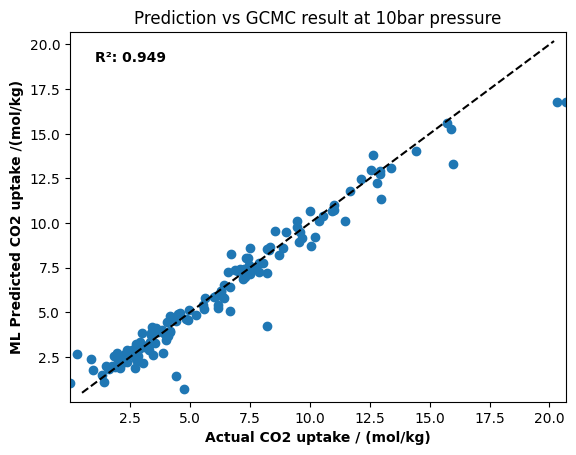

In [ ]:
for i in range(1,5):
  train_autoML( co2_data, i, all_features, save_prefix= 'all (co2)')

rdf

In [ ]:
def rdf_oxy(data):
    df = data.iloc[:, 115:]  # rdfs
    df_n = np.array(df)
    return df_n

def co2_rdf(data):
    df = data.iloc[:, 19:]   # rdf
    df_n = np.array(df)
    return df_n

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.40506232418475774
          rank  ensemble_weight           type      cost   duration
model_id                                                           
62           1             0.25    extra_trees  0.883355  29.236295
248          2             0.25       adaboost  0.907747   2.359812
266          3             0.25  decision_tree  0.933318   2.008426
221          4             0.25            sgd  0.952746   3.654412


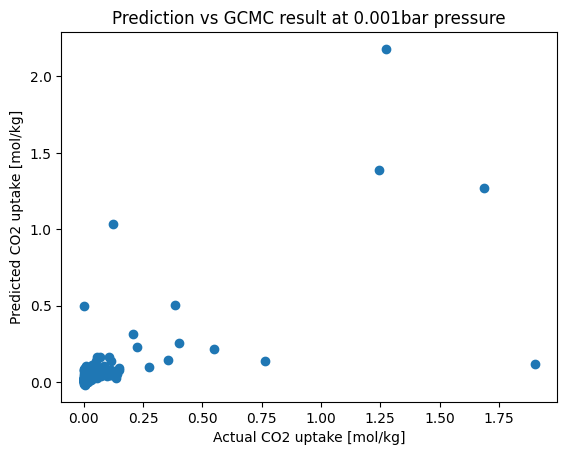

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.5180040435079855
          rank  ensemble_weight            type      cost   duration
model_id                                                            
91           1             0.25        adaboost  0.322615  36.654679
41           2             0.25        adaboost  0.352583  12.770056
306          3             0.25             sgd  0.455142   1.268883
79           4             0.25  ard_regression  0.460492  10.988382


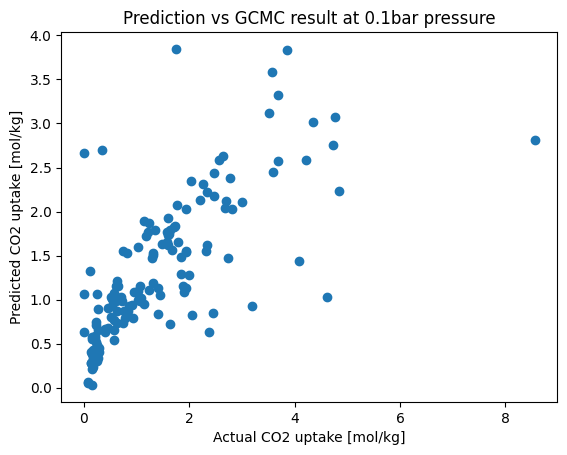

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.6183922149054264
          rank  ensemble_weight            type      cost   duration
model_id                                                            
182          1             0.50  ard_regression  0.338691   7.397097
19           2             0.25     extra_trees  0.342287  30.265519
219          3             0.25             mlp  0.378562  19.122162


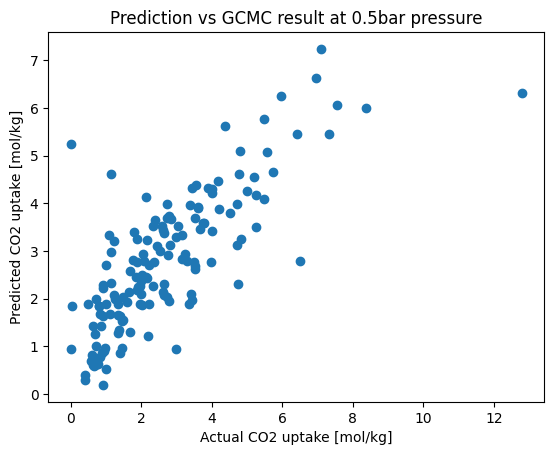

In [ ]:
for i in range(1,5):
  train_autoML( oxy_data, i, rdf_oxy)

('Prediction:', '10bar_mol_kg')
R_squared on test set:  0.8311970584894566
          rank  ensemble_weight               type      cost   duration
model_id                                                               
104          1             0.25  gradient_boosting  0.149612  72.294999
91           2             0.25  gradient_boosting  0.162669   9.784053
182          3             0.25      liblinear_svr  0.180697   4.588105
49           4             0.25  gradient_boosting  0.203055  12.105803


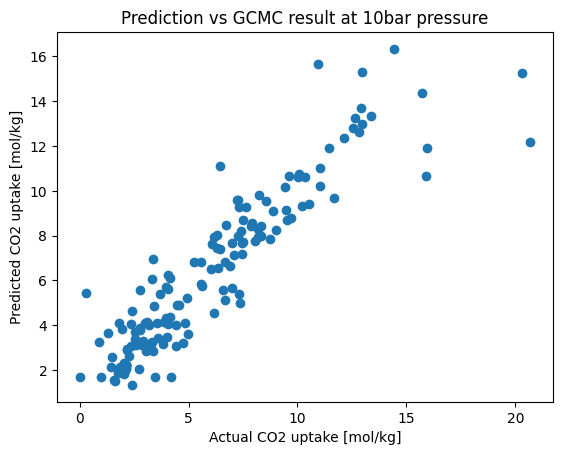

In [ ]:
for i in range(4,5):
  train_autoML( oxy_data, i, rdf_oxy)

('Prediction:', '0.001bar_mol_kg')
R_squared on test set:  0.06860181209670935
          rank  ensemble_weight           type      cost   duration
model_id                                                           
210          1             0.25    extra_trees  0.341309  15.458089
137          2             0.25            sgd  0.407059   3.776443
204          3             0.25            sgd  0.492179  31.232310
57           4             0.25  random_forest  0.530594  51.723999


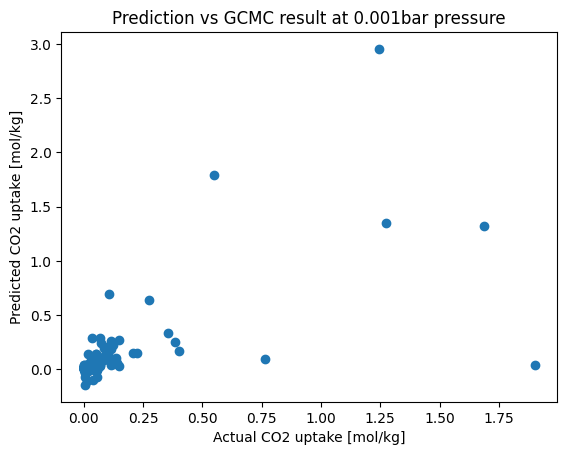

('Prediction:', '0.1bar_mol_kg')
R_squared on test set:  0.7169955195197266
          rank  ensemble_weight               type      cost   duration
model_id                                                               
162          1             0.25  gradient_boosting  0.129871  12.726380
84           2             0.25                mlp  0.135329   8.559545
99           3             0.25           adaboost  0.136726   9.513216
241          4             0.25         libsvm_svr  0.186829  15.312680


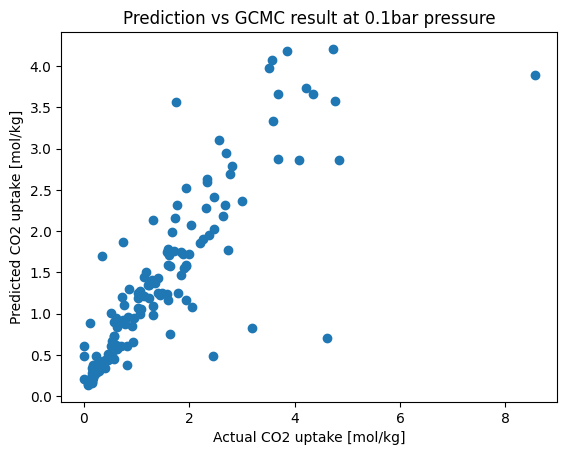

('Prediction:', '0.5bar_mol_kg')
R_squared on test set:  0.7911629544084509
          rank  ensemble_weight               type      cost   duration
model_id                                                               
21           1             0.25  gradient_boosting  0.167375  34.236520
117          2             0.25   gaussian_process  0.183572  76.194817
45           3             0.25  gradient_boosting  0.223706  40.872683
169          4             0.25                mlp  0.248283  24.881645


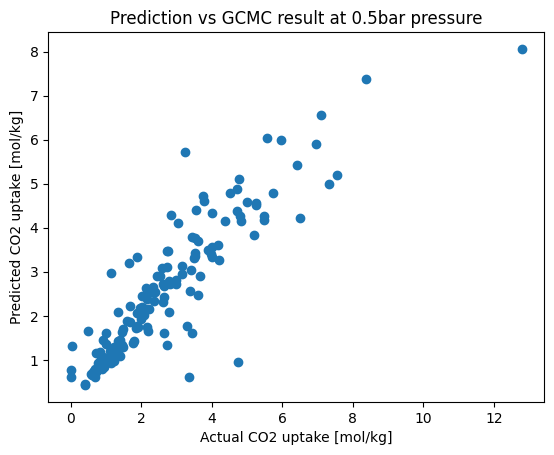

In [ ]:
for i in range(1,5):
  train_autoML( co2_data, i, co2_rdf)

## Predict on COF

In [ ]:
import joblib
import numpy as np
from sklearn.metrics import  r2_score
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load the model
COF_data = pd.read_csv('/content/COF_total_features.csv')
COF_data.head()

# View the hyperparameters of the model
#params = model.get_params()
#print("Model Hyperparameters:", params)

,FrameworkName,0.1bar,0.5bar,10bar,LCD,PLD,Access_SA_m2/g,Density,AV_cm3_g,Hist_surface,...,Value_96,Value_97,Value_98,Value_99,Value_100,Value_101,Value_102,Value_103,Value_104,Value_105
0,05000N2,3.116166,6.018834,7.620425,4.22868,3.10007,1811.09,0.909019,0.040285,2620.238372,...,1.450526,0.723803,0.529580,0.490149,0.874417,1.048502,0.730357,0.489347,0.474080,0.548825
1,05001N2,0.165388,0.802269,9.901952,23.65787,23.42513,1869.39,0.583969,0.882333,1155.951629,...,0.445459,0.324539,0.253213,0.209937,0.180992,0.159566,0.200193,0.230058,0.224081,0.212645
2,07000N2,0.129834,0.644636,9.435623,31.52022,31.34049,2100.52,0.446760,1.343220,1305.363249,...,0.427146,0.309246,0.241726,0.199172,0.171082,0.150785,0.186193,0.218935,0.211020,0.198743
3,07001N2,0.239398,1.300377,7.341923,9.14896,8.56216,1351.10,0.996063,0.201006,863.652418,...,0.480420,0.355877,0.287782,0.268848,0.290238,0.227654,0.203379,0.200727,0.213994,0.215402
4,07002N2,0.197558,1.009299,12.236829,16.54198,16.21639,1785.11,0.698051,0.553112,1122.906912,...,0.443749,0.324020,0.253514,0.211723,0.182909,0.162020,0.186268,0.227539,0.229057,0.229702


In [ ]:
def all_features(data):
  df = data.iloc[:, 4:]
  df_n = np.array(df)
  return df_n

In [ ]:

def predict_COF(data, target, features_fxn, model_path):
    data = data.fillna(0)
    target_name = target_names(data, target)
    features = features_fxn(data)
    targets = data_targets(data, target)


    model = joblib.load(model_path)
    y_pred = model.predict(features)
    r_score = r2_score(targets, y_pred)

    # Print results
    #print(target_name)
    print('R_squared on test set: ', r_score)
    print(model.leaderboard())
    print(model.show_models())
    #print(model.get_params())

    # Save the predictions
    #predictions_filename = os.path.join(prediction_save_path, )
    #np.savetxt(f'{target_name[1].split("_")[0]}_auto_predictions.txt', y_pred, fmt='%f')

    # Plot predictions vs actual results with consistent axis scales
    plt.scatter(targets, y_pred)
    plt.title(f'Prediction vs GCMC result at {target_name[1].split("_")[0]} pressure')
    plt.xlabel('Actual CO2 uptake /(mol/kg)', fontsize=10, fontweight='bold')
    plt.ylabel('ML Predicted CO2 uptake /(mol/kg)', fontsize=10, fontweight='bold')
    # Calculate min and max values for the axis limits
    min_val = min(targets.min(), y_pred.min())
    max_val = max(targets.max(), y_pred.max())

    # Plot your data
    plt.plot([min_val + 0.5 , max_val - 0.5], [min_val+0.5, max_val-0.5], 'k--')  # Black diagonal line

    # Set limits to ensure the same scale and include all points
    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    #plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--')  # Black diagonal line
    plt.text(0.05, 0.95, f'R²: {r_score:.3f}', ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, fontweight='bold')

    # Save the plot to a PNG file
    plot_filename = f'{target_name[1].split("_")[0]} pressure.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()

R_squared on test set:  0.6444073847521696
          rank  ensemble_weight              type      cost   duration
model_id                                                              
22           1             0.25  gaussian_process  0.105842  93.177243
189          2             0.25               mlp  0.137504   5.730621
222          3             0.25  gaussian_process  0.151483  89.341182
83           4             0.25               mlp  0.183520   7.502179
{22: {'model_id': 22, 'rank': 1, 'cost': 0.10584157576264208, 'ensemble_weight': 0.25, 'data_preprocessor': <autosklearn.pipeline.components.data_preprocessing.DataPreprocessorChoice object at 0x7fdea1cdf6a0>, 'feature_preprocessor': <autosklearn.pipeline.components.feature_preprocessing.FeaturePreprocessorChoice object at 0x7fde9d2058d0>, 'regressor': <autosklearn.pipeline.components.regression.RegressorChoice object at 0x7fde9d206e60>, 'sklearn_regressor': GaussianProcessRegressor(alpha=0.42928092501196696,
                

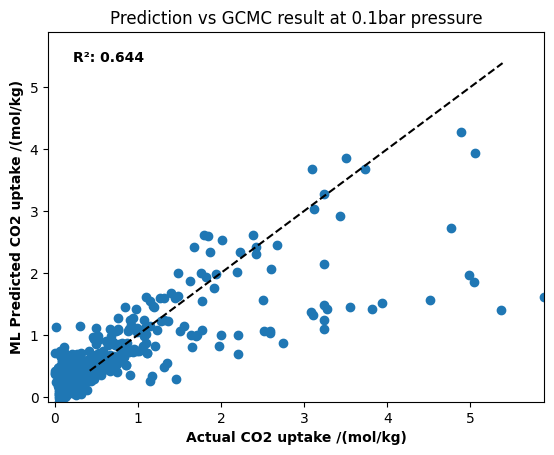

In [ ]:
#co2 automl 0.1bar
model = '/content/drive/MyDrive/UoM Dissertation/result/models/all (co2)_0.1bar_auto_model.joblib'
predict_COF(COF_data, 1, all_features, model_path= model)

R_squared on test set:  0.6154713806471189
          rank  ensemble_weight               type      cost   duration
model_id                                                               
260          1             0.25  gradient_boosting  0.140061   6.368643
109          2             0.25         libsvm_svr  0.155046   5.648995
162          3             0.25  gradient_boosting  0.197388  80.768010
25           4             0.25         libsvm_svr  0.212554  19.497796
{25: {'model_id': 25, 'rank': 1, 'cost': 0.21255350413428142, 'ensemble_weight': 0.25, 'data_preprocessor': <autosklearn.pipeline.components.data_preprocessing.DataPreprocessorChoice object at 0x7fdea13a8640>, 'feature_preprocessor': <autosklearn.pipeline.components.feature_preprocessing.FeaturePreprocessorChoice object at 0x7fde9cc4a9e0>, 'regressor': <autosklearn.pipeline.components.regression.RegressorChoice object at 0x7fde9cc4b490>, 'sklearn_regressor': SVR(C=194.03096694114694, cache_size=1959.0390625,
    epsilon

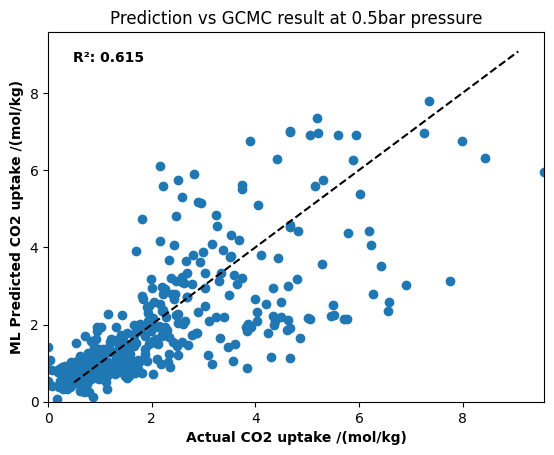

In [ ]:
#co2 automl 0.5bar
model = '/content/drive/MyDrive/UoM Dissertation/result/models/all (co2)_0.5bar_auto_model.joblib'
predict_COF(COF_data, 2, all_features, model_path= model)

R_squared on test set:  0.646067365034485
          rank  ensemble_weight               type      cost   duration
model_id                                                               
64           1             0.25  gradient_boosting  0.033601  15.149362
4            2             0.25   gaussian_process  0.041766  72.331625
25           3             0.25         libsvm_svr  0.044030  15.621605
66           4             0.25      liblinear_svr  0.065763   1.986973
{4: {'model_id': 4, 'rank': 1, 'cost': 0.04176644042002742, 'ensemble_weight': 0.25, 'data_preprocessor': <autosklearn.pipeline.components.data_preprocessing.DataPreprocessorChoice object at 0x7fde9d2c9180>, 'feature_preprocessor': <autosklearn.pipeline.components.feature_preprocessing.FeaturePreprocessorChoice object at 0x7fde9cfd9cc0>, 'regressor': <autosklearn.pipeline.components.regression.RegressorChoice object at 0x7fdea182c6a0>, 'sklearn_regressor': GaussianProcessRegressor(alpha=0.02341626598167312,
             

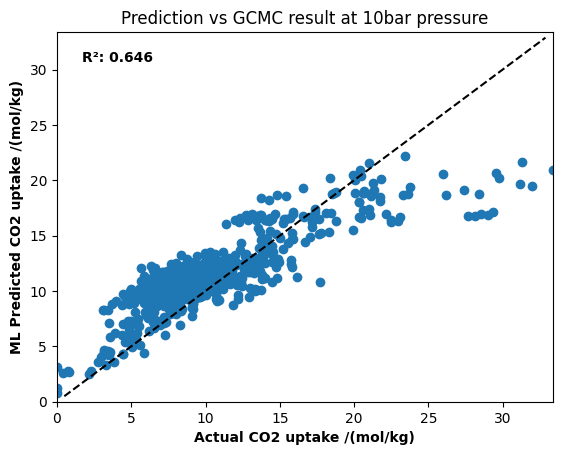

In [ ]:
#co2 automl 10bar
model = '/content/drive/MyDrive/UoM Dissertation/result/models/all (co2)_10bar_auto_model.joblib'
predict_COF(COF_data, 3, all_features, model_path= model)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [13:37:18] WARNING: /workspace/src/collective/../data/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


('Prediction:', '0.1bar')
R_squared on test set:  0.6917696317135138
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


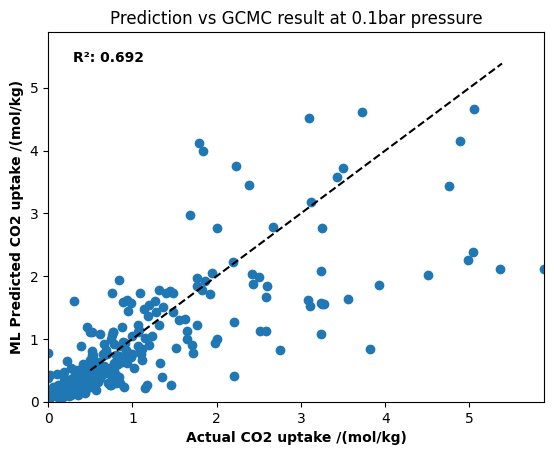

In [ ]:
#co2 xgb 0.1bar
model = '/content/drive/MyDrive/UoM Dissertation/result/models/all (co2)_0.1bar_xgb_model.joblib'
predict_COF(COF_data, 1, all_features, model_path= model)

('Prediction:', '0.5bar')
R_squared on test set:  0.5999964403320818
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


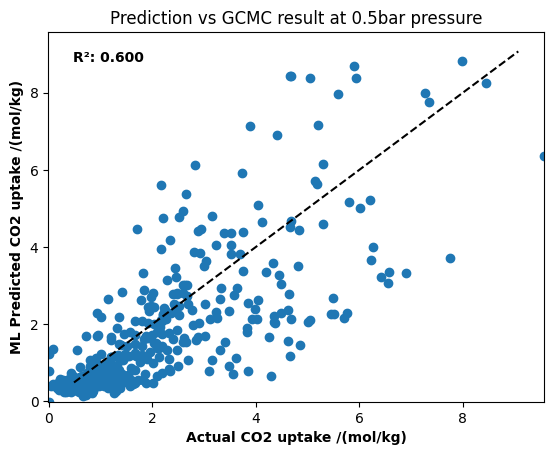

In [ ]:
#co2 xgb 0.5bar
model = '/content/drive/MyDrive/UoM Dissertation/result/models/all (co2)_0.5bar_xgb_model.joblib'
predict_COF(COF_data, 2, all_features, model_path= model)

('Prediction:', '10bar')
R_squared on test set:  0.6750113818690859
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 2000, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


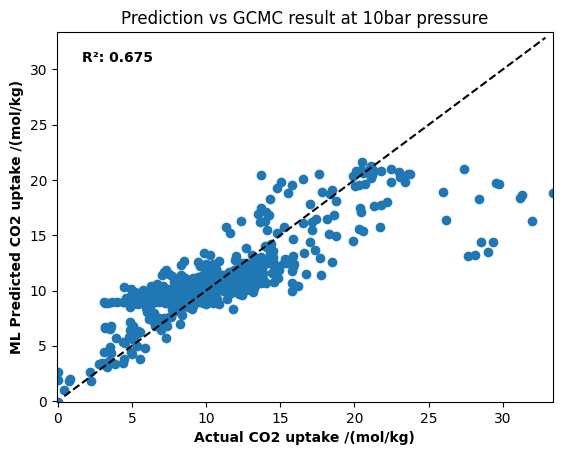

In [ ]:
#co2 xgb 10bar
model = '/content/drive/MyDrive/UoM Dissertation/result/models/all (co2)_10bar_xgb_model.joblib'
predict_COF(COF_data, 3, all_features, model_path= model)

In [ ]:
import pandas as pd
crafted = pd.read_csv('/content/CRAFTED_uptake_geometric.csv')
crafted.head()

,FrameworkName,0.001bar_mol_kg,0.1bar_mol_kg,0.5bar_mol_kg,10bar_mol_kg,LCD,PLD,Access_SA_m2/g,Density,AV_cm3_g
0,MUVHER,0.051678,2.484930,4.850875,7.381888,5.24679,3.73170,1841.510,0.97664,0.075038
1,LACJAC,0.039919,1.350102,1.892201,2.696235,4.56325,3.36486,619.328,1.59158,0.022236
2,ZNGLUD,0.115857,2.458963,3.347351,4.426935,3.19455,2.66271,0.000,1.65404,0.000000
3,AMUCOB,0.005819,0.359966,0.688829,1.120526,4.03894,3.31743,217.564,1.59335,0.004983
4,MIL-88C-open,0.002726,0.258265,1.282425,20.345104,13.75037,10.89185,4181.320,0.50854,0.973376


In [ ]:
cof = pd.read_csv('/content/COF_CRAFTED_uptake_geometric.csv')
cof.head()


,FrameworkName,0.1bar,0.5bar,10bar,LCD,PLD,Access_SA_m2/g,Density,AV_cm3_g
0,05000N2,3.116166,6.018834,7.620425,4.22868,3.10007,1811.09,0.909019,0.040285
1,05001N2,0.165388,0.802269,9.901952,23.65787,23.42513,1869.39,0.583969,0.882333
2,07000N2,0.129834,0.644636,9.435623,31.52022,31.34049,2100.52,0.446760,1.343220
3,07001N2,0.239398,1.300377,7.341923,9.14896,8.56216,1351.10,0.996063,0.201006
4,07002N2,0.197558,1.009299,12.236829,16.54198,16.21639,1785.11,0.698051,0.553112


Text(0, 0.5, 'Frequency')

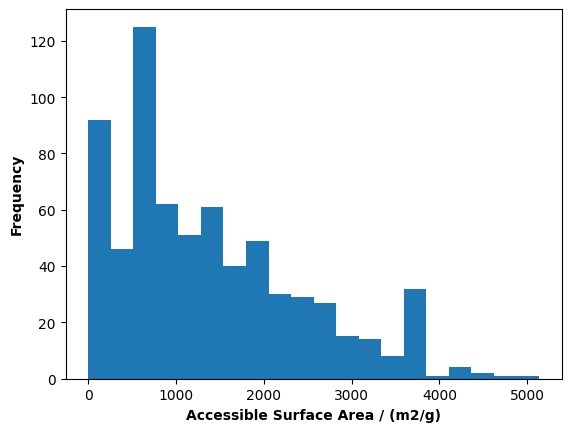

In [ ]:
import matplotlib.pyplot as plt

plt.hist(crafted['Access_SA_m2/g'], bins = 20)

plt.xlabel('Accessible Surface Area / (m2/g)', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

Text(0, 0.5, 'Frequency')

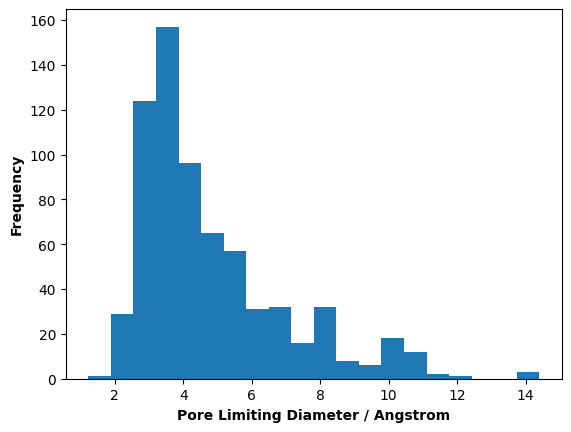

In [ ]:
plt.hist(crafted['PLD'], bins = 20)
plt.xlabel('Pore Limiting Diameter / Angstrom', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

Text(0, 0.5, 'Frequency')

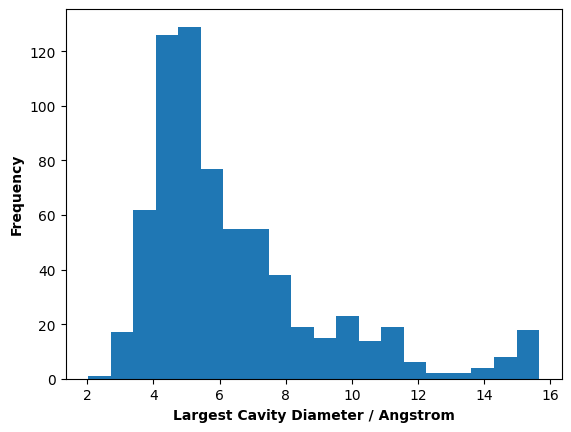

In [ ]:
plt.hist(crafted['LCD'], bins = 20)
plt.xlabel('Largest Cavity Diameter / Angstrom', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

Text(0, 0.5, 'Frequency')

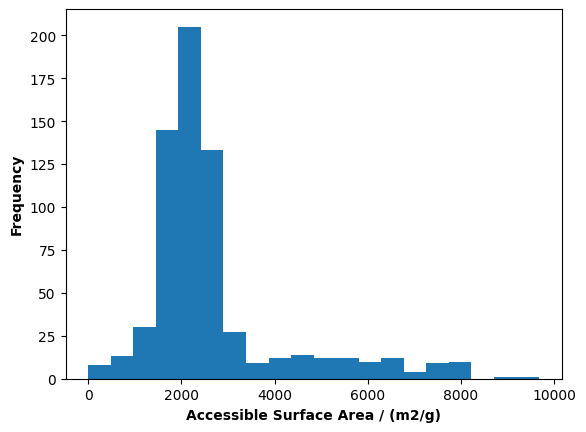

In [ ]:
plt.hist(cof['Access_SA_m2/g'], bins = 20)
plt.xlabel('Accessible Surface Area / (m2/g)', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

Text(0, 0.5, 'Frequency')

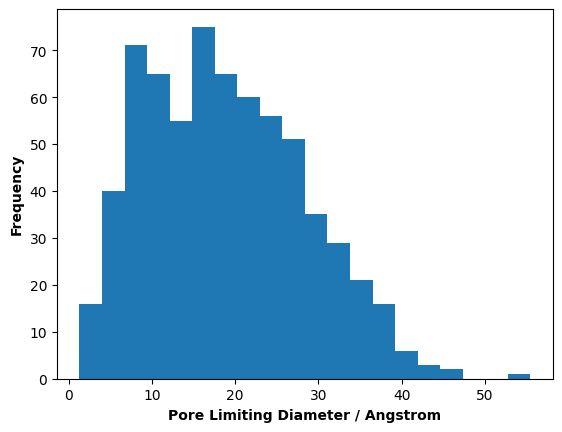

In [ ]:
plt.hist(cof['PLD'], bins = 20)
plt.xlabel('Pore Limiting Diameter / Angstrom', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

Text(0, 0.5, 'Frequency')

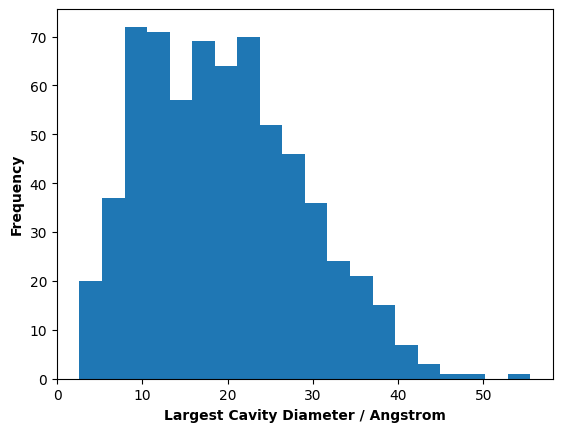

In [ ]:
plt.hist(cof['LCD'], bins = 20)
plt.xlabel('Largest Cavity Diameter / Angstrom', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

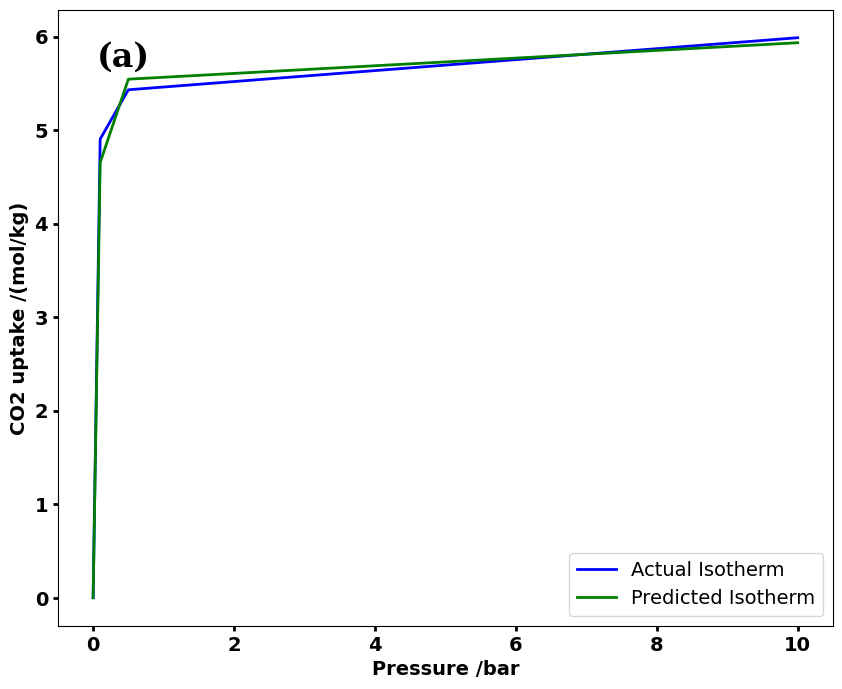

In [ ]:
import matplotlib.pyplot as plt

pressure = [0, 0.1, 0.5, 10]
actual = [0, 4.9039,5.4308, 5.9873]
predicted = [0, 4.6538, 5.5441, 5.9336]


plt.figure(figsize=(10, 8))  # Adjust figure size as needed

# Plot the curves
plt.plot(pressure, actual, label='Actual Isotherm', color='blue', linewidth=2)
plt.plot(pressure, predicted, label='Predicted Isotherm', color='green', linewidth=2)

# Add labels and title
plt.xlabel('Pressure /bar', fontsize=14, fontweight='bold')
plt.ylabel('CO2 uptake /(mol/kg)', fontsize=14, fontweight='bold')

# Set tick parameters for bold axis values
plt.tick_params(axis='both', which='major', labelsize=12, labelcolor='black', width=2)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# Add legend
plt.legend(prop={'size': 14}, loc = 'lower right')

#
plt.text(0.05, 0.95, '(a)', ha='left', va='top', transform=plt.gca().transAxes, fontsize=24, fontweight='bold', fontfamily='serif')

# Show the plot
plt.show()


# Show the plot
plt.show()


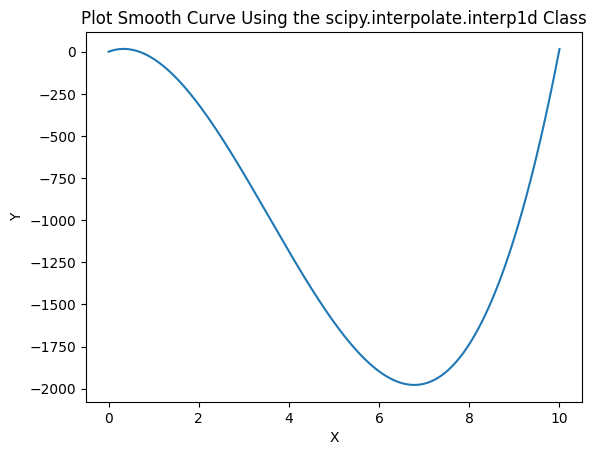

In [ ]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

# Dataset
x = np.array([0, 0.1, 0.5, 10])
y = np.array([0, 8.56, 12.78, 15.96])

cubic_interpolation_model = interp1d(x, y, kind = "cubic")

# Plotting the Graph
X_=np.linspace(x.min(), x.max(), 500)
Y_=cubic_interpolation_model(X_)

plt.plot(X_, Y_)
plt.title("Plot Smooth Curve Using the scipy.interpolate.interp1d Class")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()